In [1]:
##### Plots feature importance for final RF models

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

In [8]:
##### SET-UP

# Get the current working directory
cd = Path.cwd().parent.parent 

# import models
capital = pd.read_csv(f'{cd}/Results/RF_models_final/capital_rf_spatial_CV/feature_importance.csv')
labor = pd.read_csv(f'{cd}/Results/RF_models_final/labor_rf_spatial_CV/feature_importance.csv')

# final var names 
names = pd.read_csv(f"{cd}/Data/Correspondence_tables/final_RF_var_names.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/feature_importance"

In [11]:
### Prep data

capital = capital.merge(names, on='feature', how='left')
labor = labor.merge(names, on='feature', how='left')


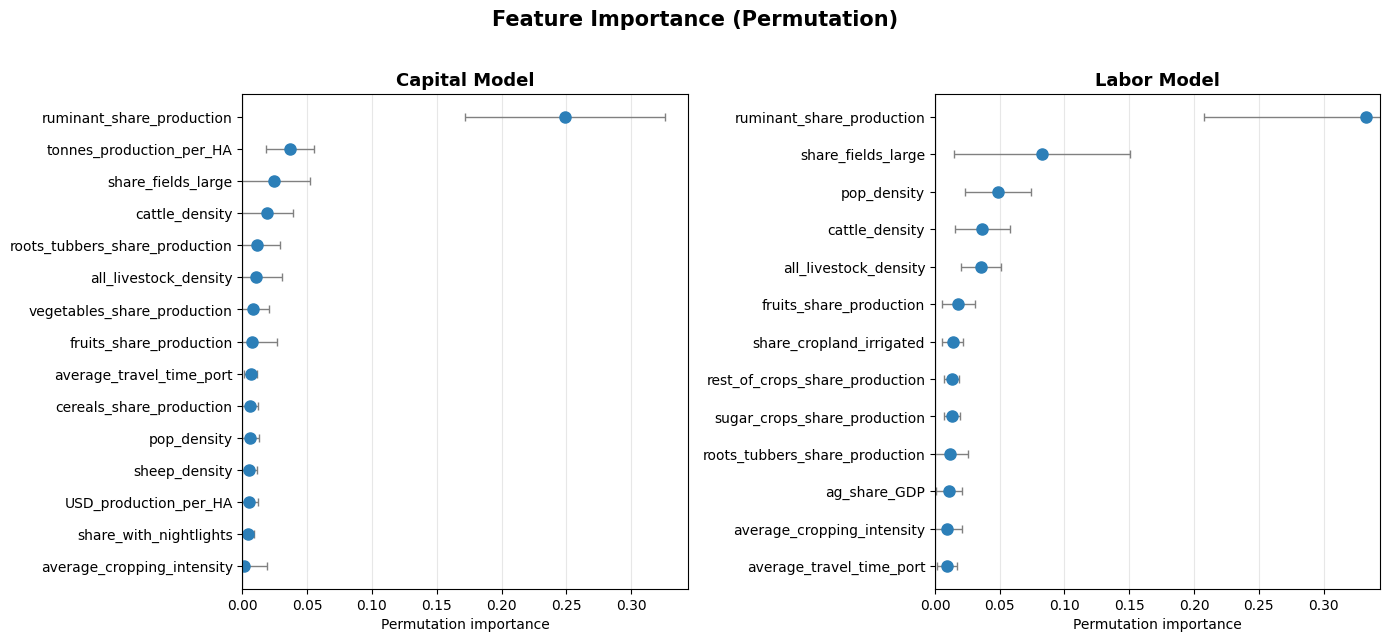

In [13]:
#### Feature importance: capital vs labor (permutation importance)

fig, axes = plt.subplots(1, 2, figsize=(14, max(len(capital), len(labor)) * 0.35 + 1), sharex=True)

def plot_feature_importance(ax, df, title, color="#2c7fb8"):
    df_sorted = df.sort_values("permutation_mean", ascending=True)

    ax.errorbar(
        df_sorted["permutation_mean"], df_sorted["name"],
        xerr=df_sorted["permutation_std"],
        fmt="o", color=color, ecolor="grey", elinewidth=1, capsize=3,
        markersize=8, zorder=2
    )

    ax.axvline(0, color="black", linewidth=0.8, zorder=1)
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel("Permutation importance", fontsize=10)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(left=0)

plot_feature_importance(axes[0], capital, "Capital Model")
plot_feature_importance(axes[1], labor, "Labor Model")

fig.suptitle("Feature Importance (Permutation)", fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/feature_importance_permutation_side_by_side.png", dpi=300, bbox_inches="tight")